# Adversarial Attacks on Post-hoc Explainability Methods

We reimplement [Fooling LIME and SHAP: Adversarial Attacks on Post-hoc Explainability Methods](https://github.com/dylan-slack/Fooling-LIME-SHAP/tree/master).

One important consideration is going to be how we implement Local ALE for classification. We should think carefully about the specific model being learned.

In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from sklearn.decomposition import PCA

from utils import Explanation
from ale import ALE
from shap import SHAP

/Users/dawsonren/miniconda3/envs/ml/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def get_and_clean_compas_data():
	"""
    Handle processing of COMPAS according to: https://github.com/propublica/compas-analysis
	"""
	PROTECTED_CLASS = 1
	POSITIVE_OUTCOME = 0
	NEGATIVE_OUTCOME = 1

	compas_df = pd.read_csv("data/compas.csv", index_col=0)

    # replicate data cleaning from original COMPAS analysis
	compas_df = compas_df.loc[(compas_df['days_b_screening_arrest'] <= 30) &
							  (compas_df['days_b_screening_arrest'] >= -30) &
							  (compas_df['is_recid'] != -1) &
							  (compas_df['c_charge_degree'] != "O") &
							  (compas_df['score_text'] != "NA")]
	compas_df['length_of_stay'] = (pd.to_datetime(compas_df['c_jail_out']) - pd.to_datetime(compas_df['c_jail_in'])).dt.days

    # reduce number of columns
	X = compas_df[['age', 'two_year_recid', 'c_charge_degree', 'race', 'sex', 'priors_count', 'length_of_stay']]

	# high scores (higher risk of recidivism) leads to negative outcomes
	y = np.array([NEGATIVE_OUTCOME if score == 'High' else POSITIVE_OUTCOME for score in compas_df['score_text']])
	sens = X.pop('race')

	# assign African-American as the protected class
	X = pd.get_dummies(X)
	sensitive_attr = np.array(pd.get_dummies(sens).pop('African-American'))
	X['is_african_american'] = sensitive_attr

	# make sure everything is lining up
	assert all((sens == 'African-American') == (X['is_african_american'] == PROTECTED_CLASS))
	
	return X, y

In [3]:
X_compas, y_compas = get_and_clean_compas_data()

## PCA Experiment

We show that the perturbations created by ALE are in some sense "milder" than the ones created by LIME and KernelSHAP.

In [4]:
def plot_2d_compas_pca(X_compas, explainer_class: Explanation, explain_n=100):
    # only take numerical features
    X_numerical = X_compas[["age", "priors_count", "length_of_stay"]].to_numpy()
    dummy_f = lambda x: x
    explainer = explainer_class(dummy_f, X_numerical, verbose=False)
    if isinstance(explainer, ALE):
        explainer.explain()
    for i in range(explain_n):
        explainer.explain_local(X_numerical[i, :])
    X_perturbed = explainer.get_query_points()

    all_x = np.vstack((X_perturbed, X_numerical))
    pca = PCA(n_components=2)
    results = pca.fit_transform(all_x)

    # plot all original and perturbed data points
    plt.scatter(results[:X_perturbed.shape[0], 0], results[:X_perturbed.shape[0], 1], alpha=.1, color='red', label='Perturbed Data')
    plt.scatter(results[-X_numerical.shape[0]:, 0], results[-X_numerical.shape[0]:, 1], alpha=.1, color='blue', label='Original Data')
    plt.xlabel('PCA Component 1')
    plt.ylabel('PCA Component 2')
    plt.title(f'PCA of Original and Perturbed Data using {explainer_class.__name__}')
    plt.legend()
    plt.show()


/Users/dawsonren/Desktop/Experiments/ExplainableML/ale/tree_partitioning.py:290: UserWarning: generate_connected_delta_values: all features flat, splitting on first variable
  warnings.warn(


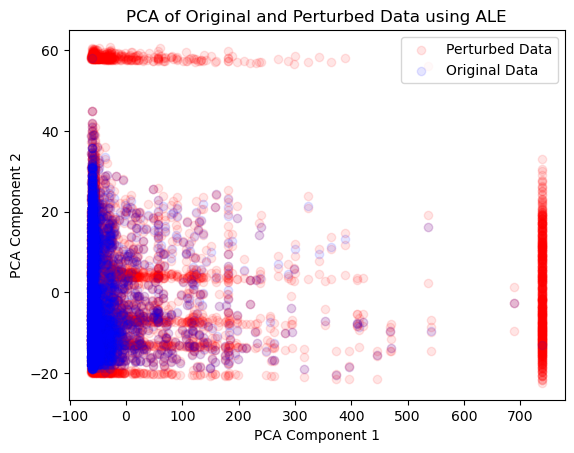

In [5]:
plot_2d_compas_pca(X_compas, ALE, explain_n=1)

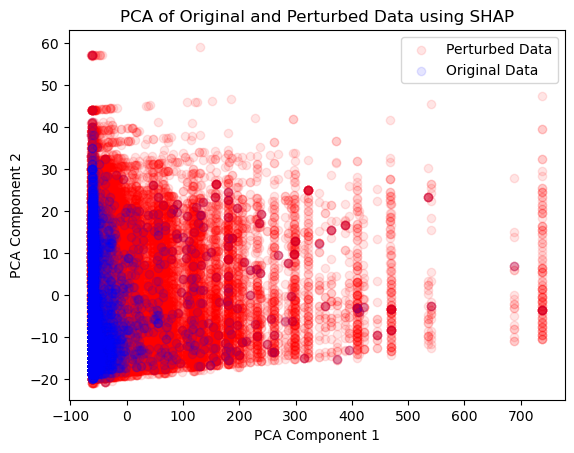

In [7]:
plot_2d_compas_pca(X_compas, SHAP, explain_n=1000)

# COMPAS Experiment

In [ ]:
def train_ood_classifier(X)